In [2]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

In [3]:
# fit values

GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935
gamma_meV: float = 0.005066874981090785
eta: float = 0.002173
nu_GHz: float = 13.6

eta = 0.002173  # (3)
Aoff_mV = -6.2e-3  # (13) mV
Tbase_K = 0.0806  # (46) K
Toff_K = -0.685  # (194) K
alphaT = 2.6811  # (458)

In [4]:
# # import from pickle

# HOME_DIR = "/Users/oliver/Documents/cryolab/p5control-bluefors-evaluation"
# sys.path.append(HOME_DIR)

# from utilities.ivplot import IVPlot

# importlib.reload(sys.modules["utilities.ivplot"])

# eva = IVPlot()
# eva.title = f"amplitude at 13.6GHz"
# eva.sub_folder = (
#     "/Users/oliver/Documents/cryolab/superconductivity/evaluation/TB irradiation/data/"
# )
# eva.loadData()

# Vbias_mV = eva.mapped["voltage_axis"] * 1e3
# Ibias_nA = eva.mapped["current_axis"] * 1e9
# Aout_mV = eva.mapped["y_axis"] * 1e3
# dGexp_G0 = eva.up_sweep["differential_conductance"]
# dRexp_R0 = eva.up_sweep["differential_resistance"] * sc.G0_muS / 1e6
# Iexp_nA = eva.up_sweep["current"] * 1e9

In [5]:
# import from pickle

HOME_DIR = "/Users/oliver/Documents/cryolab/p5control-bluefors-evaluation"
sys.path.append(HOME_DIR)

from utilities.ivplot import IVPlot

importlib.reload(sys.modules["utilities.ivplot"])

eva = IVPlot()
eva.title = f"amplitude at 18.3GHz"
eva.sub_folder = (
    "/Users/oliver/Documents/cryolab/superconductivity/evaluation/TB irradiation/data/"
)
eva.loadData()

Vbias_mV = eva.mapped["voltage_axis"] * 1e3
Ibias_nA = eva.mapped["current_axis"] * 1e9
Aout_mV = eva.mapped["y_axis"] * 1e3
dGexp_G0 = eva.up_sweep["differential_conductance"]
dRexp_R0 = eva.up_sweep["differential_resistance"] * sc.G0_muS / 1e6
Iexp_nA = eva.up_sweep["current"] * 1e9

(base) ... BaseClass initialized.
(base eva) ... BaseEvaluation initialized.
(iv eva) ... IVEvaluation initialized.
(base) ... BaseClass initialized.
(base plot) ... BasePlot initialized.
(iv plot) ... IVPlot initialized.
(base) amplitude at 18.3GHz
(base) loadData()


In [6]:
# data to plot
nu_GHz = 18.3
eta = 0.00084489
Delta_meV = 0.1955424661339017

Vbias = Vbias_mV / Delta_meV
Abias = Aout_mV * (eta) / (sc.h_pVs * nu_GHz)
Ibias = Ibias_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Iexp = Iexp_nA / (Delta_meV * GN_G0 * sc.G0_muS)
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0

Aintrest = [0, 0.96586225, 1.93172449, 3.09075919, 4.05662144]

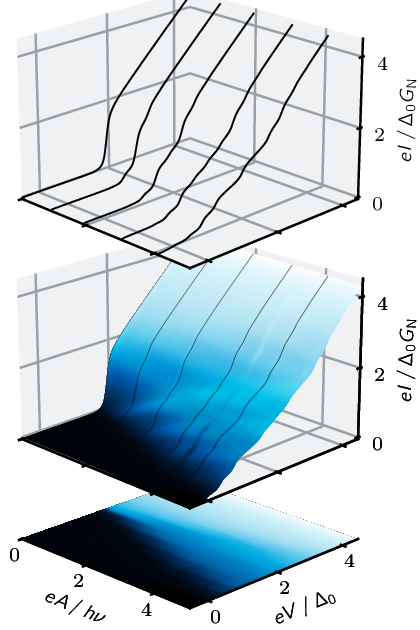

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_raw_iv/main.png

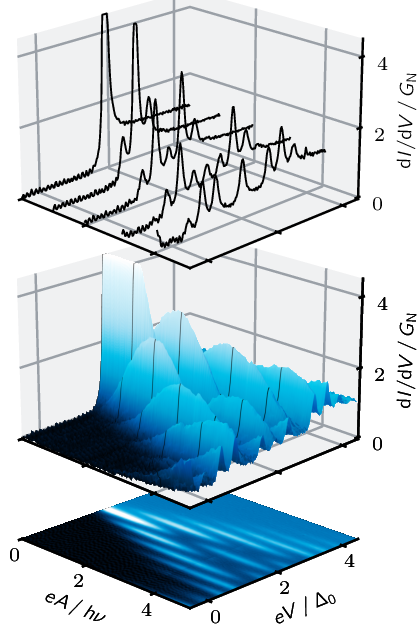

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_raw_didv/main.png

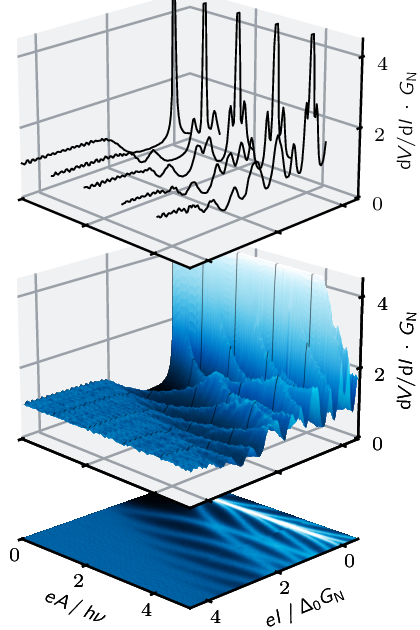

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_raw_dvdi/main.png

In [7]:
# export the composite plots
import superconductivity.visuals.thesis.latex as thesis_latex

importlib.reload(thesis_latex)
export_amplitude_maps_thesis = thesis_latex.export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias,
    Abias,
    Ibias,
    Iexp,
    dGexp,
    dRexp,
    name="amp_raw",
    waterfall_traces=Aintrest,
    sub_dir="tunnelbarrier/highres",
)

In [8]:
# import importlib
# import superconductivity.optimizers.pat as pat

# importlib.reload(pat)

# solution = pat.fit_pats(
#     V_mV=Vbias_mV,
#     I_nA=Iexp_nA,
#     show_progress=True,
# )

In [9]:
# # Test fit one curve
# from superconductivity.optimizers.old_pat.fit_pat import fit_I_nA
# from superconductivity.optimizers.old_pat.show_fitting import show_fitting, show_stats

# importlib.reload(sys.modules["superconductivity.optimizers.old_pat.fit_pat"])
# importlib.reload(sys.modules["superconductivity.optimizers.old_pat.show_fitting"])

# solution0 = fit_I_nA(
#     V_mV=Vbias_mV,
#     I_nA=Iexp_nA[0, :],
#     GN_G0=(0.18907387255862304, (0.1, 0.3), False),
#     T_K=(0.23393265069546368, (0.0, 1.0), False),
#     Delta_meV=(0.1955352791293755, (0.180, 0.2), False),
#     gamma_meV=(0.004379851077615499, (1e-4, 30e-3), False),
#     model="dynes",
# )
# show_fitting(solution0, num=0)
# show_stats(solution0)

In [10]:
# # fit the whole thing

# I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype="float64")
# A_fit_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
# A_fit_err_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
# T_fit_K = np.full_like(Aout_mV, np.nan, dtype="float64")
# T_fit_err_K = np.full_like(Aout_mV, np.nan, dtype="float64")

# from superconductivity.optimizers.fit_pat import SolutionDict

# solutions: list[SolutionDict] = []
# for i, _ in enumerate(tqdm(Aout_mV)):
#     if i > 1:
#         a_mV = A_fit_mV[i - 1]
#     else:
#         a_mV = 0.0
#     solution = fit_I_nA(
#         V_mV=Vbias_mV,
#         I_nA=Iexp_nA[i, :],
#         GN_G0=(solution0["GN_G0"], (0.1, 0.3), True),
#         T_K=(solution0["T_K"], (0.0, 1.2), False),
#         Delta_meV=(solution0["Delta_mV"], (0.190, 0.2), True),
#         gamma_meV=(solution0["gamma_mV"], (1e-4, 30e-3), True),
#         A_mV=(a_mV, (0, 4), False),
#         nu_GHz=(nu_GHz, (nu_GHz * 0.9, nu_GHz * 1.1), False),
#         model="dynes+pat",
#         optimizer="curve_fit",
#     )
#     I_fit_nA[i, :] = solution["I_fit_nA"]
#     A_fit_mV[i] = solution["A_mV"]
#     T_fit_K[i] = solution["T_K"]

#     T_fit_err_K[i] = solution["perr"][1]
#     A_fit_err_mV[i] = solution["perr"][4]
#     solutions.append(solution)

In [11]:
# from scipy.optimize import curve_fit


# def calibration_A(x_data, eta: float, A_off: float):
#     A_cal = A_off + eta * x_data
#     return A_cal


# A_popt, A_pcov = curve_fit(
#     f=calibration_A,
#     xdata=np.array(Aout_mV, dtype="float64"),
#     ydata=np.array(A_fit_mV, dtype="float64"),
# )
# A_perr = np.sqrt(np.diag(A_pcov))
# A_popt